In [1]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [1]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("Housing.csv")  # df means data frame
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [6]:
df.info() ##it gives the csv file information

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [7]:
df.describe() #it returns the numerical columns statistical info

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
df.describe(include="str")
#df.describe(include="int64")

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


In [9]:
#check duplicates
df.duplicated().sum()

np.int64(0)

In [10]:
##get columns
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [11]:
categorical_columns=[ 'mainroad','guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
numerical_columns=['price','area','parking','bedrooms','bathrooms','stories','parking']

In [12]:
df['mainroad']

0      yes
1      yes
2      yes
3      yes
4      yes
      ... 
540    yes
541     no
542    yes
543     no
544    yes
Name: mainroad, Length: 545, dtype: str

In [13]:
df[categorical_columns]

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,yes,no,yes,no,furnished
...,...,...,...,...,...,...,...
540,yes,no,yes,no,no,no,unfurnished
541,no,no,no,no,no,no,semi-furnished
542,yes,no,no,no,no,no,unfurnished
543,no,no,no,no,no,no,furnished


In [14]:
df['mainroad'].unique()

<StringArray>
['yes', 'no']
Length: 2, dtype: str

In [15]:
##data transformation
#updating categprical columns values

In [22]:
map_value={'yes':1,'no':0}
df['mainroad']=df['mainroad'].replace(map_value)
df['guestroom']=df['guestroom'].replace(map_value)
df['basement']=df['basement'].replace(map_value)
df['hotwaterheating']=df['hotwaterheating'].replace(map_value)
df['airconditioning']=df['airconditioning'].replace(map_value)
df['prefarea']=df['prefarea'].replace(map_value)
values={'furnished':1,'semi-furnished':0.5,'unfurnished':0}
df['furnishingstatus']=df['furnishingstatus'].replace(values)
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0.5
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,0.5
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,1


In [23]:
map_value={'yes':1,'no':0}
df['mainroad']=df['mainroad'].astype('int32')
df['guestroom']=df['guestroom'].astype('int32')
df['basement']=df['basement'].astype('int32')
df['hotwaterheating']=df['hotwaterheating'].astype('int32')
df['airconditioning']=df['airconditioning'].astype('int32')
df['prefarea']=df['prefarea'].astype('int32')
#values={'furnished':1,'semi-furnished':0.5,'unfurnished':0}
df['furnishingstatus']=df['furnishingstatus'].astype('int32')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,1


In [24]:
df['furnishingstatus'].unique()

array([1, 0], dtype=int32)

In [25]:
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad            int32
guestroom           int32
basement            int32
hotwaterheating     int32
airconditioning     int32
parking             int64
prefarea            int32
furnishingstatus    int32
dtype: object

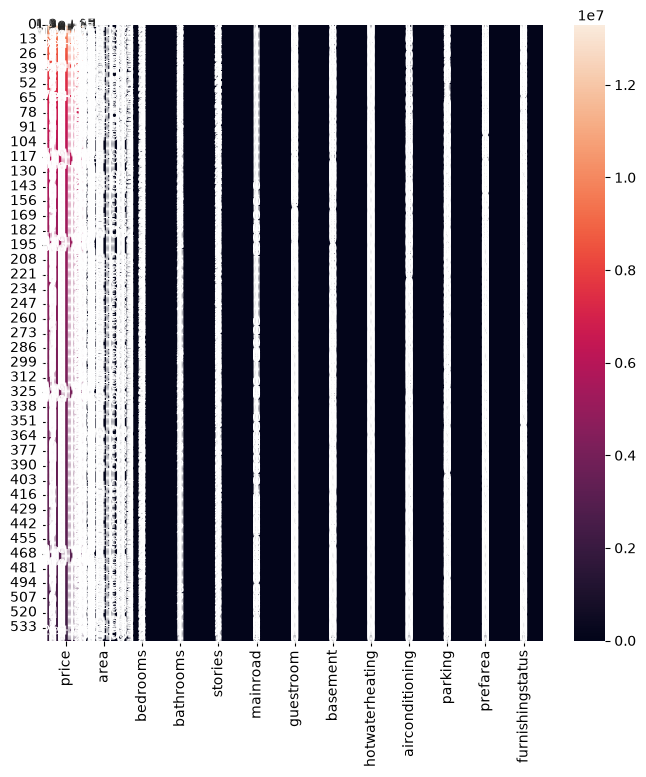

In [26]:
#data visualization
#heatmap
plt.figure(figsize=(8,8))
sns.heatmap(data=df,annot=True)
plt.show()

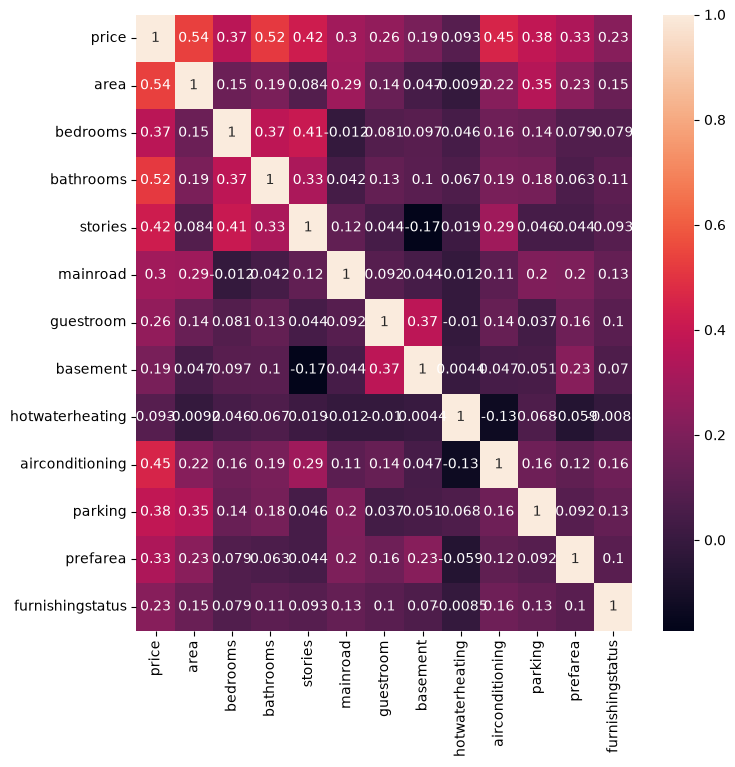

In [27]:
#data visualization
#heatmap
plt.figure(figsize=(8,8))
sns.heatmap(data=df.corr(),annot=True)
plt.show()

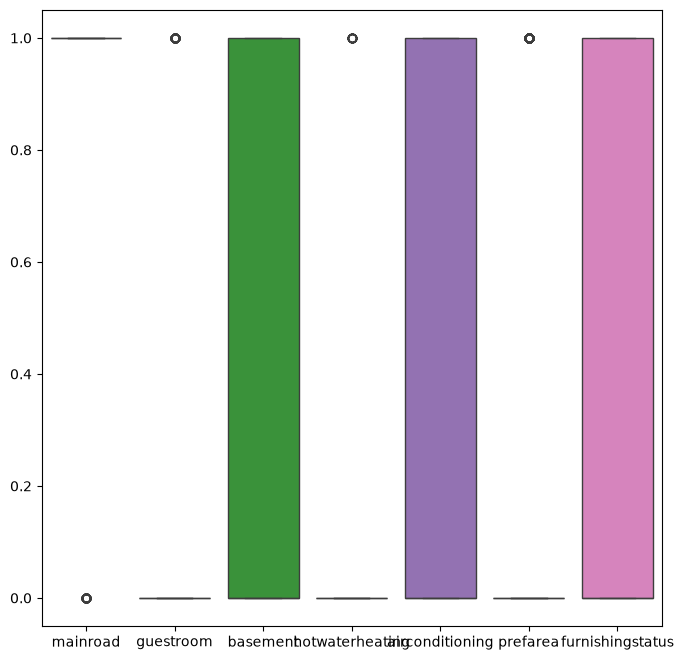

In [28]:
#boxplot
plt.figure(figsize=(8,8))
sns.boxplot(data=df[categorical_columns])
plt.show()


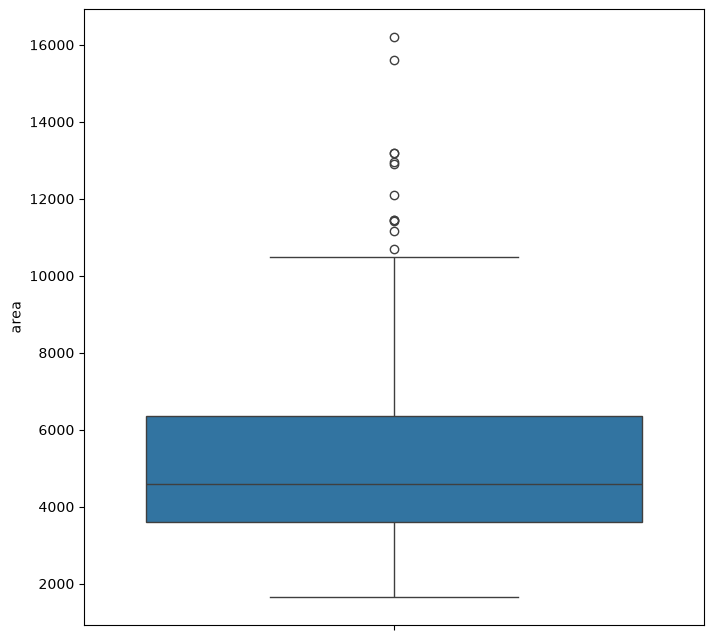

In [29]:
#boxplot
plt.figure(figsize=(8,8))
sns.boxplot(data=df['area'])
plt.show()


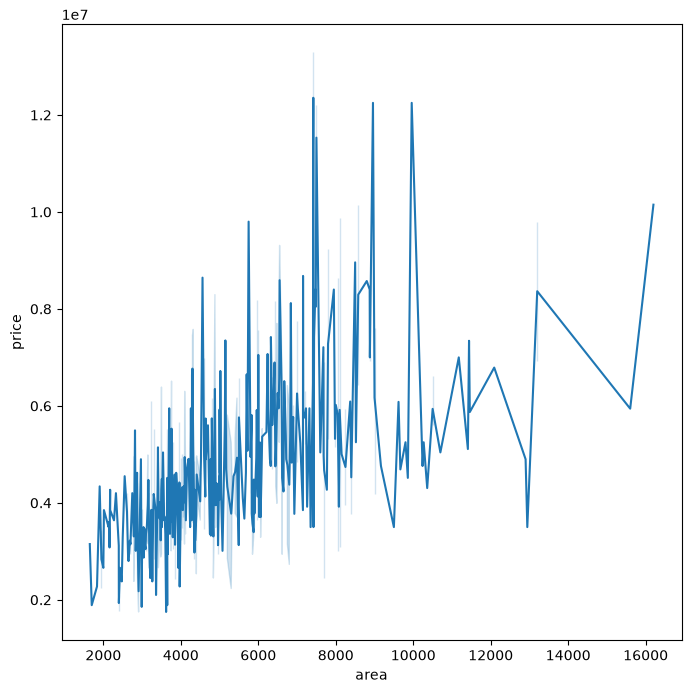

In [30]:
#lineplot
#boxplot
plt.figure(figsize=(8,8))
sns.lineplot(data=df,x='area',y='price')
plt.show()


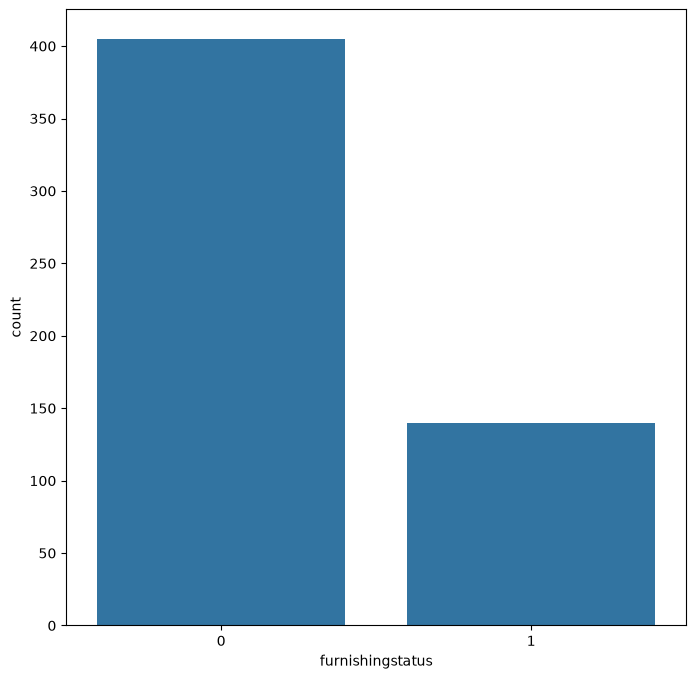

In [31]:
#countplot
#boxplot
plt.figure(figsize=(8,8))
sns.countplot(data=df,x='furnishingstatus')
plt.show()


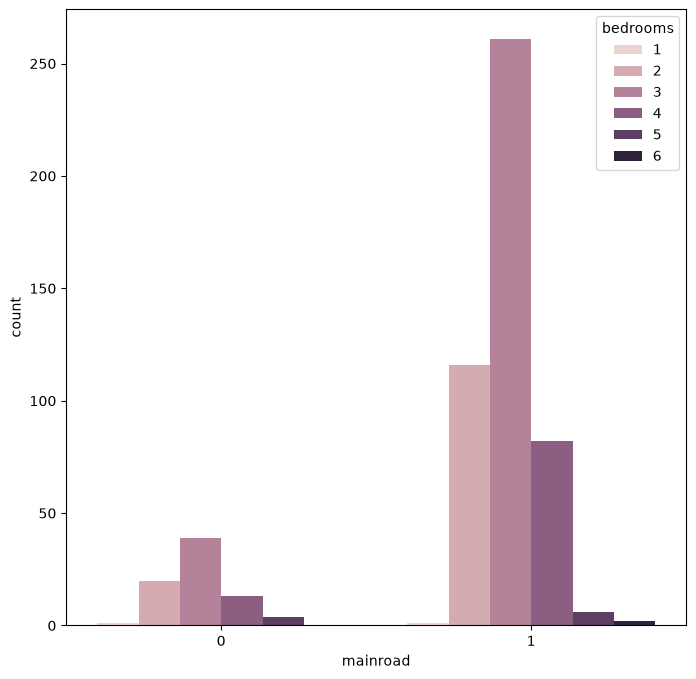

In [32]:
#countplot
#boxplot
plt.figure(figsize=(8,8))
sns.countplot(data=df,x='mainroad',hue='bedrooms')
plt.show()


<Figure size 800x800 with 0 Axes>

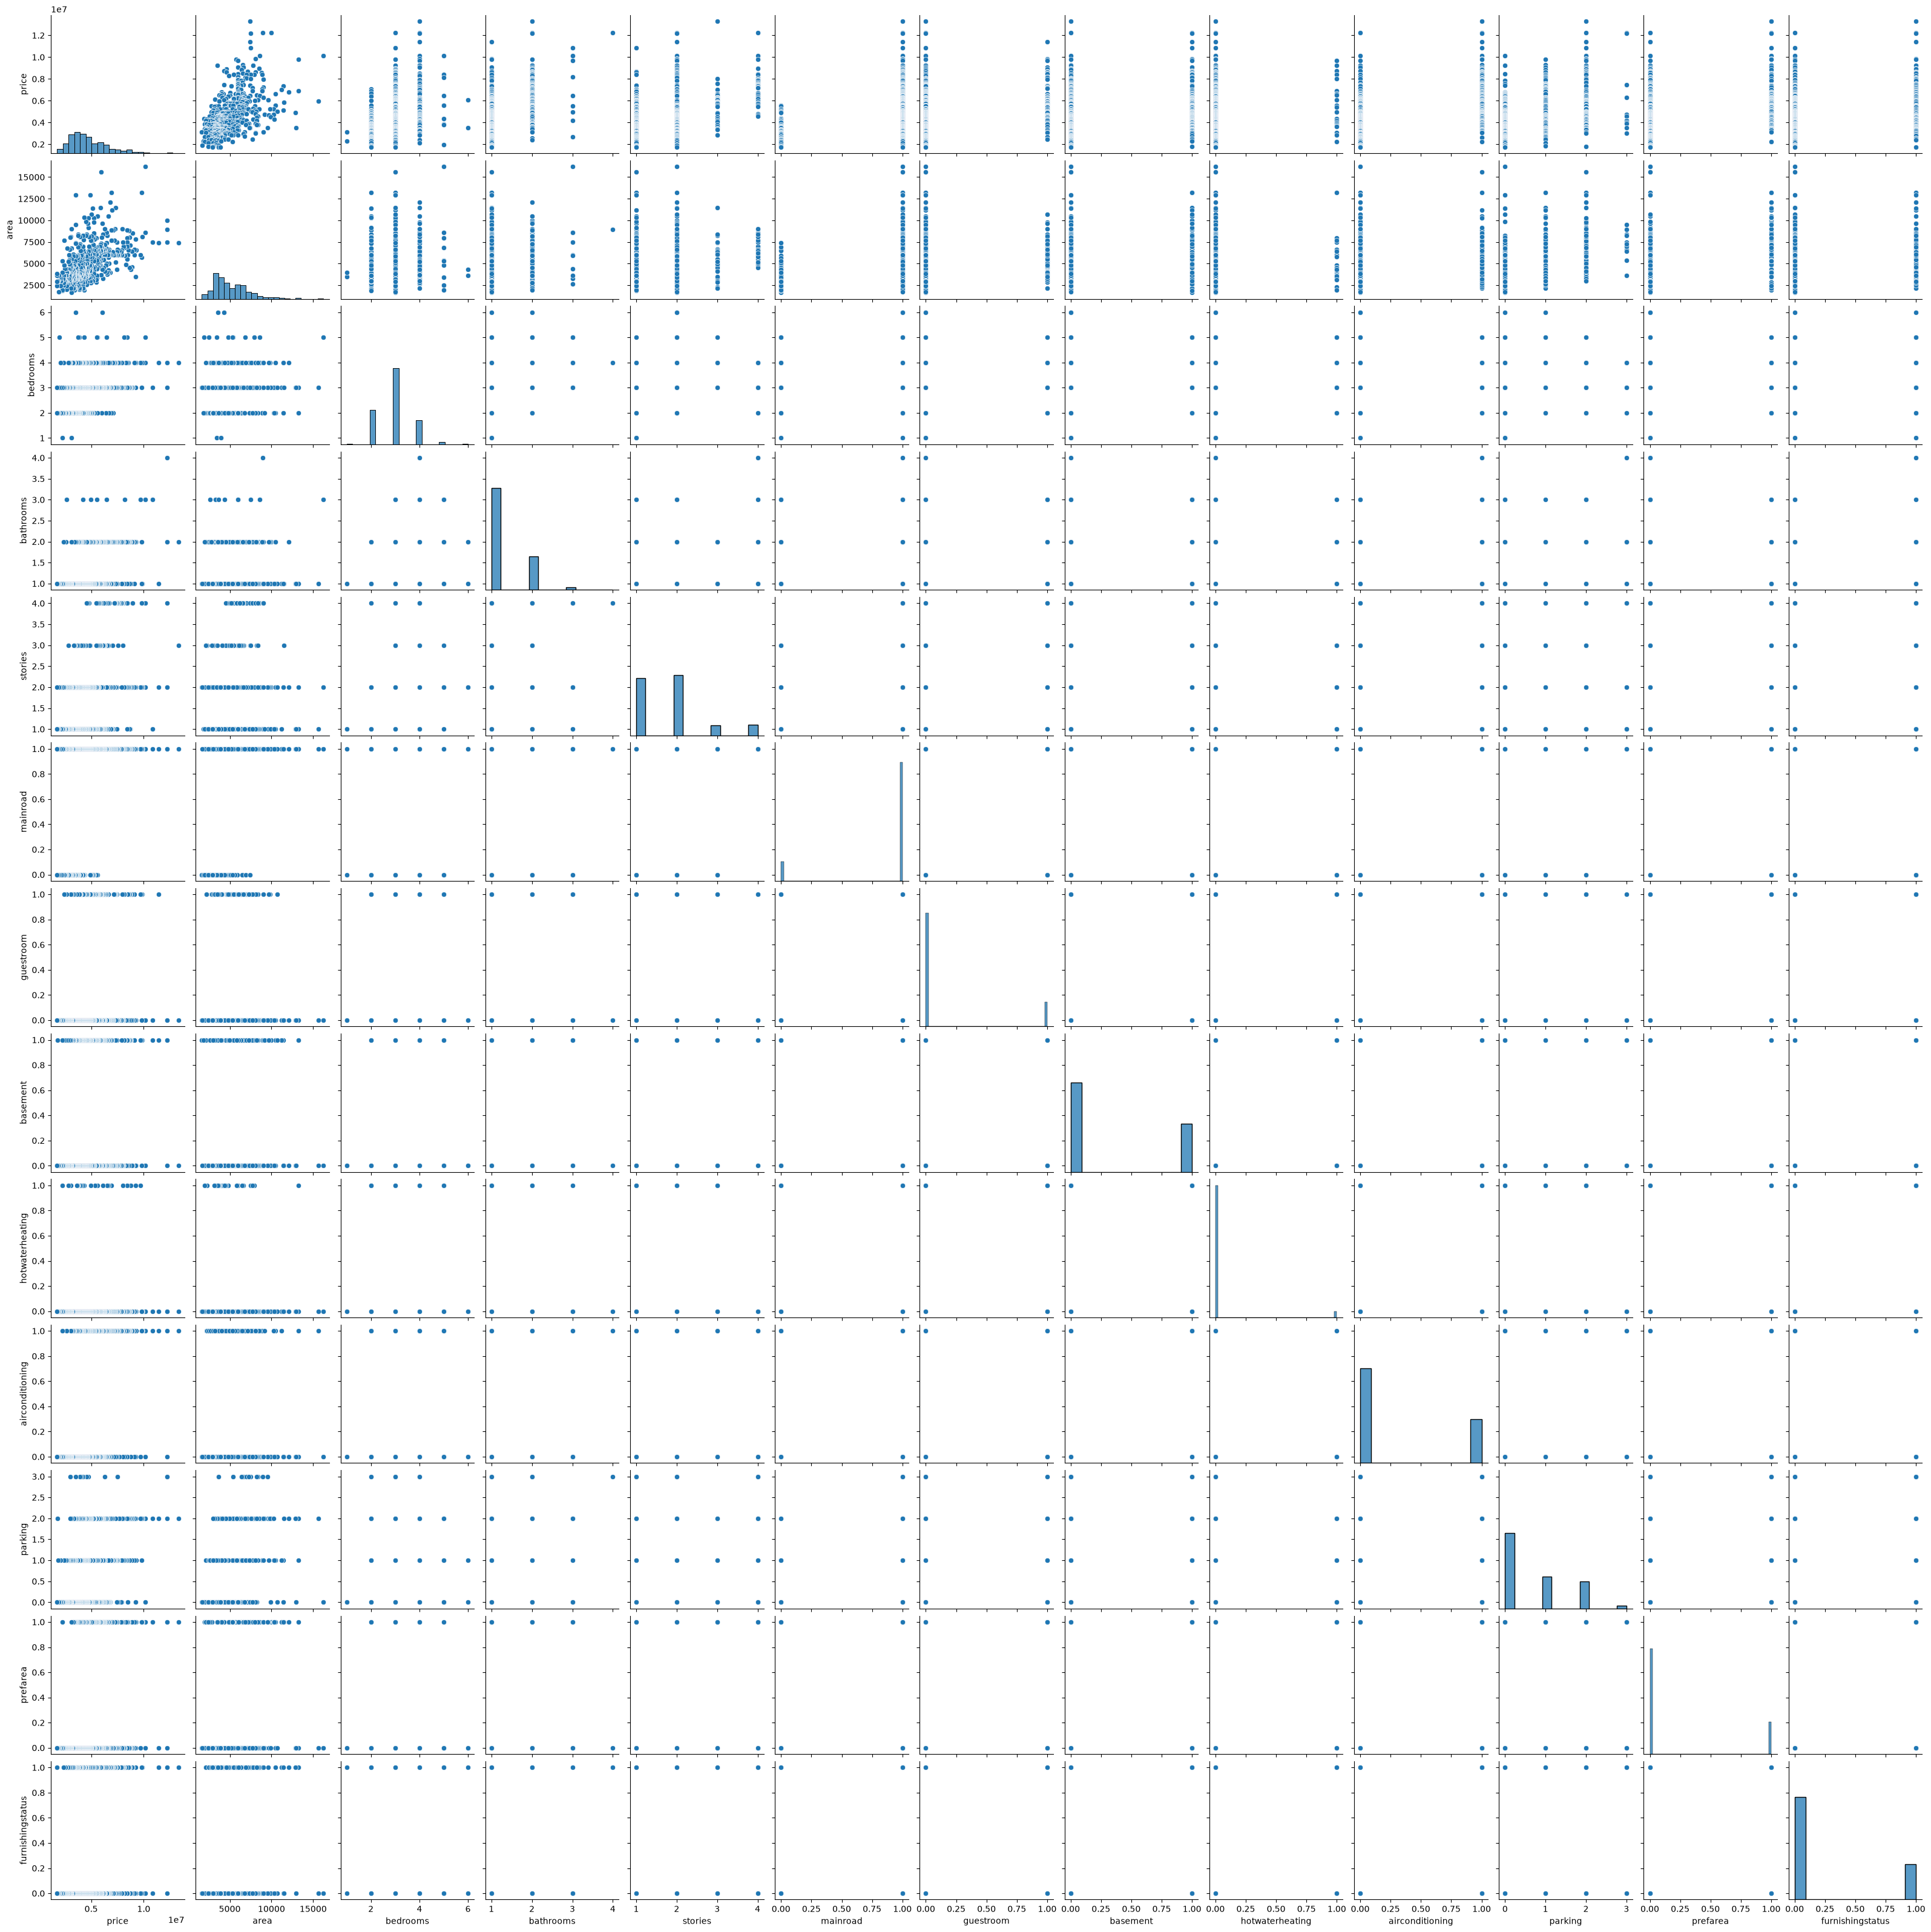

In [33]:
##countplot
#pair plot
plt.figure(figsize=(8,8))
sns.pairplot(data=df)
plt.show()